In [1]:
import pandas as pd
from statsbombpy import sb
df_raw = sb.events(match_id= 3869685)

c:\Users\pawan\anaconda34\envs\dataAnalysisPython\lib\site-packages\statsbombpy\api_client.py:21: NoAuthWarning: credentials were not supplied. open data access only
  warnings.warn(


In [2]:
df = df_raw.copy(deep = True)

In [3]:
df.head()

,50_50,bad_behaviour_card,ball_receipt_outcome,ball_recovery_offensive,ball_recovery_recovery_failure,block_deflection,block_offensive,carry_end_location,clearance_aerial_won,clearance_body_part,...,substitution_outcome,substitution_outcome_id,substitution_replacement,substitution_replacement_id,tactics,team,team_id,timestamp,type,under_pressure
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,"{'formation': 433, 'lineup': [{'player': {'id'...",Argentina,779,00:00:00.000,Starting XI,NaN
1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,"{'formation': 4231, 'lineup': [{'player': {'id...",France,771,00:00:00.000,Starting XI,NaN
2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,France,771,00:00:00.000,Half Start,NaN
3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,Argentina,779,00:00:00.000,Half Start,NaN
4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,France,771,00:00:00.000,Half Start,NaN


In [4]:
df = df[df['type'] == 'Pass']

In [5]:
df[['x', 'y']] = df['location'].apply(pd.Series)

In [6]:
df = df[df['pass_outcome'].isna()]

Text(0.5, 1.0, 'Argentina Starting Succesfull pass locations vs France')

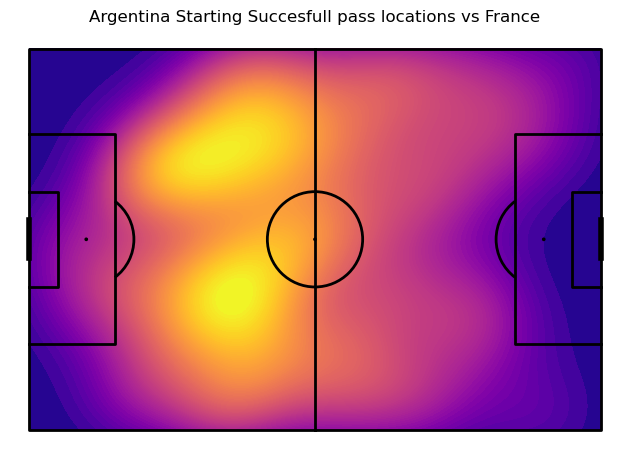

In [11]:
from mplsoccer import Pitch

pitch = Pitch(pitch_type = 'statsbomb', pitch_color= 'white', line_color = 'black', line_zorder=2)

fig, ax = pitch.draw()

df_arg = df[df['team_id'] == 779]

kde = pitch.kdeplot(
    df_arg.x,
    df_arg.y,
    fill = True,
    thresh = 0,
    n_levels = 100,
    cut = 10,
    ax= ax,
    cmap = 'plasma'
)


ax.set_title('Argentina Starting Succesfull pass locations vs France')